# RESERVOIR QUALITY ANALYSIS

### PROJECT OBJECTIVE: This project focuses on identifying the best quality of rock (reservoir) using data logic.

### WORKFLOW:
1. Import Libraries
2. Dataset Loading and Cleaning
3. Statistical Facies Discrimination
4. Feature Engineering
5. NetPay Quantification

###  IMPORT LIBRARIES

In [1]:
import lasio as l    
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### DATASET LOADING AND CLEANING

• Load the provided Well_A.las file using lasio.

• Convert to a Pandas DataFrame and handle the NULL values specifically using the las.well.NULL.value reference.

• Display the well metadata and curve information.

• Identify and plot the key tracks needed for reservoir analysis: GR (Use a 60 API cutoff), RT, RHOB, and NPHI.

In [2]:
las = l.read(r"C:\Users\AYOMIDE\OneDrive\Desktop\GCA Dataset\Well_A.las")
las

### WELL INFORMATION

In [3]:
print("Well Metadata")
for item in las.well:
    print(f"  {item.mnemonic}: {item.value}")
    
print('                                       ')

print('CURVE INFORMATION')
for curve in las.curves:
    print(f"{curve.mnemonic:10} | {curve.unit:10} | {curve.descr}")

Well Metadata
  STRT: 4901.0
  STEP: 0.5
  STOP: 7991.0
  NULL: -999.25
  WELL: Well_B
  XWELL: 789112
  YWELL: 123456
  EDF: 61.86
                                       
CURVE INFORMATION
DEPT       | ft         | DEPTH
CALF       | in         | 12
SON3       | us/ft      | 10
FDC        | g/cm3      | 7
VSH        | fract      | 6
RT         | ohm.m      | 4
POR        | fract      | 3
GR_NM      | API        | 1


In [4]:
# Convert las file to a dataframe
df = las.df().reset_index()
null_value = las.well.NULL.value
df.replace(null_value, np.nan, inplace=True)

print(f"Null value replaced: {null_value}")
print(f"Shape: {df.shape}")

# Statistical Summary of Curves
df.describe().T

Null value replaced: -999.25
Shape: (6181, 8)


,count,mean,std,min,25%,50%,75%,max
DEPT,6181.0,6446.000000,892.222669,4901.0000,5673.500000,6446.0000,7218.50000,7991.0000
CALF,4701.0,10.684091,0.915736,9.5500,10.010900,10.4163,11.03050,13.8319
SON3,5765.0,106.711312,10.073077,67.5487,99.836200,106.0941,113.22370,158.4982
FDC,5099.0,2.041632,0.141557,1.5202,1.963300,2.0621,2.13190,2.4573
VSH,4627.0,0.309673,0.339908,0.0002,0.000200,0.1917,0.55195,1.0000
RT,5783.0,49.124654,141.442633,1.1793,5.339550,11.6397,27.08840,1206.1689
POR,3842.0,0.260560,0.085487,0.0000,0.250825,0.2905,0.32000,0.3200
GR_NM,5645.0,65.092757,28.709408,9.2415,41.184200,57.9688,92.08800,177.0449


In [5]:
df[df['CALF'] > 11]

,DEPT,CALF,SON3,FDC,VSH,RT,POR,GR_NM
398,5100.0,11.5967,117.1555,1.8892,NaN,103.4548,NaN,NaN
399,5100.5,11.5967,131.8813,1.8589,NaN,99.6776,NaN,NaN
400,5101.0,11.5966,141.9612,1.8198,NaN,89.1108,NaN,NaN
401,5101.5,11.6281,133.6920,1.7831,NaN,82.4273,NaN,NaN
402,5102.0,11.6635,158.4982,1.7216,NaN,77.8121,NaN,NaN
...,...,...,...,...,...,...,...,...
4928,7365.0,11.0462,113.6175,2.1752,0.8313,1.7588,NaN,103.5925
4929,7365.5,11.0462,114.4050,2.1767,0.8440,1.7007,NaN,104.7383
4930,7366.0,11.0232,114.4837,2.1979,0.8825,1.7008,NaN,105.8606
4932,7367.0,11.0462,114.1687,2.2318,0.9324,1.7010,NaN,104.7168


In [6]:
df[df['CALF'] <= 11]

,DEPT,CALF,SON3,FDC,VSH,RT,POR,GR_NM
411,5106.5,10.9977,136.4454,2.0440,NaN,24.2550,NaN,NaN
412,5107.0,10.9391,132.5076,2.0544,NaN,21.1050,NaN,NaN
413,5107.5,10.8874,128.2951,2.0319,NaN,21.1050,NaN,NaN
414,5108.0,10.8610,123.9545,2.0194,NaN,18.1693,NaN,NaN
415,5108.5,10.8401,119.5131,1.9917,NaN,17.0100,NaN,NaN
...,...,...,...,...,...,...,...,...
5094,7448.0,9.7540,95.6625,2.2057,0.6860,13.2177,0.1536,99.8457
5095,7448.5,9.7390,95.1113,2.1746,0.5364,13.2178,0.1515,98.0176
5096,7449.0,9.7390,93.9300,2.1642,0.4670,13.2180,0.1470,95.1797
5097,7449.5,9.7390,93.5362,2.1621,0.4554,13.2571,0.1455,89.1484


In [7]:
# Check for NaN values
df.isna().sum()

DEPT        0
CALF     1480
SON3      416
FDC      1082
VSH      1554
RT        398
POR      2339
GR_NM     536
dtype: int64

In [8]:
# Check dataset for duplicate rows
df.duplicated().sum()

0

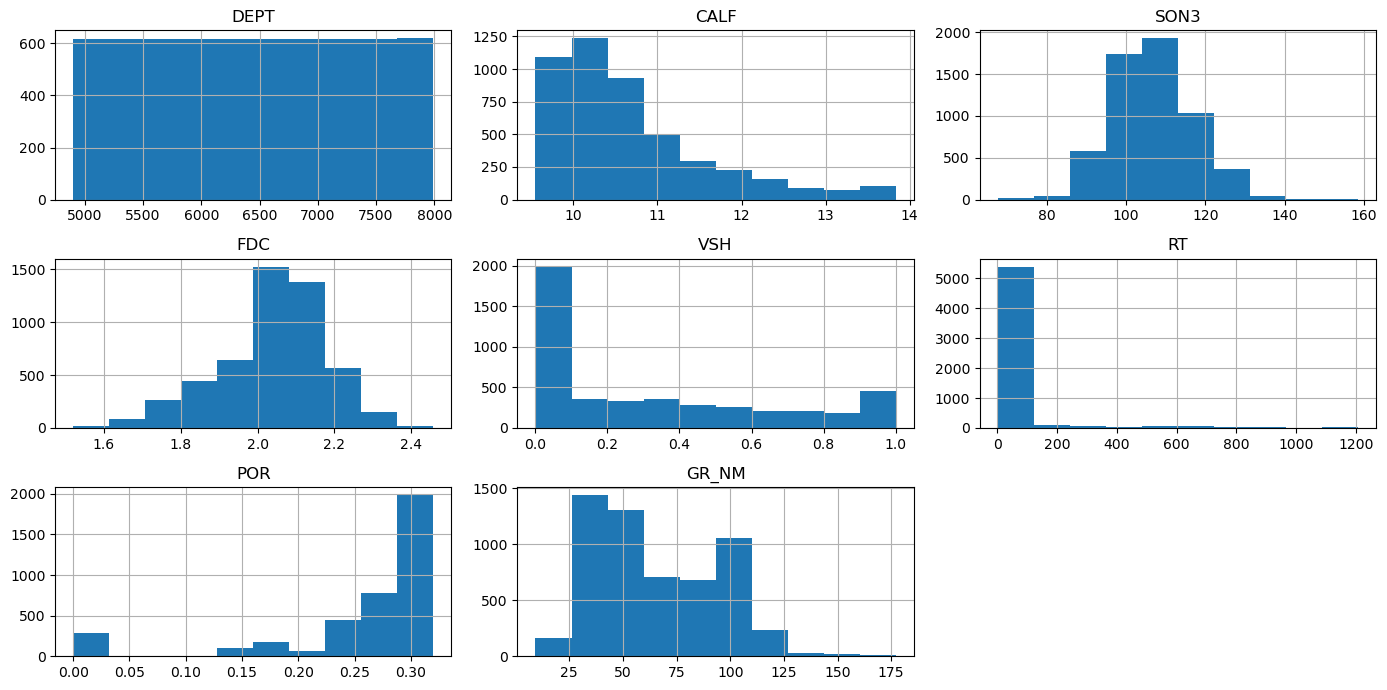

In [9]:
df.hist(figsize = (14,7))
plt.tight_layout();

DEPT (Depth, ft): The near-uniform distribution from ~4,800 to ~8,000 ft indicates this is a continuous well log dataset with consistent depth sampling, at 0.5 ft intervals. The flatness is expected and simply confirms that no major washout zones caused data gaps.

CALF (Caliper, in): Strongly right-skewed, peaking around 9–10 inches and tapering toward 14 inches. This is classic behaviour — most of the borehole is close to the bit size (9 bit), meaning relatively stable formation. The right tail indicates washout intervals.

SON3 (Sonic/DT, µs/ft): This looks Bimodal, peaking around 95–100 µs/ft and 105–110 µs/ft. Sonic is useful for lithology separation and pore pressure prediction in deltaic sequences.  the lower peak likely corresponds to cleaner, more compacted sands, while the higher peak reflects shales or more porous intervals.

FDC (Formation Density Compensated, g/cc): Peaks sharply around 2.0–2.2 g/cc with a slight left skew. This range is consistent with a mixture of sand (~2.65 g/cc matrix, with porosity pulling density down) and shale intervals. Values below 2.0 g/cc may indicate very high porosity zones or fluid-filled intervals, while values toward 2.4–2.5 g/cc indicate tighter, more compacted rock.

VSH (Volume of Shale, fraction): Strongly concentrated near 0.0 (very clean) with a secondary population around 0.8–1.0 (near-pure shale). This bimodal shape is characteristic of a deltaic interbedded sand-shale sequence. It suggests we have well-differentiated lithologies. This is a good potential for net pay delineation using a VSH cutoff (typically VSH < 0.3–0.4 for sand).

RT (True Resistivity, ohm·m): Extremely right-skewed, with the vast majority of readings below 100 ohm·m and a long tail extending to ~1,200 ohm·m. High resistivity values (100+ ohm·m) are the classic signature of hydrocarbon-bearing reservoirs. The bulk of low values represents water-saturated sands and shales. 

POR (Porosity, fraction): This shows a bimodal distribution with a low-porosity cluster near 0.05 and a dominant peak near 0.28–0.32. The high-porosity peak (25–35%) is typical of unconsolidated to semi-consolidated Niger Delta sands, with excellent reservoir quality. The low-porosity cluster may reflect tight sands or shales. 

GR_NM (Gamma Ray Normalized, API): This peaks broadly between 25–125 API, suggesting a mix of clean sands (GR < 60 API) and shales (GR > 75–100 API). The spread toward 175 API suggests some radioactive or uranium-rich shale intervals.

Overall, this dataset is consistent with a Niger Delta well penetrating an interbedded fluvio-deltaic sand-shale sequence at moderate depths (~5,000–8,000 ft). The distributions collectively point to good net reservoir potential, high porosity sands, resistive pay intervals, and clear lithological differentiation.

### Key Tracks for Reservoir Analysis

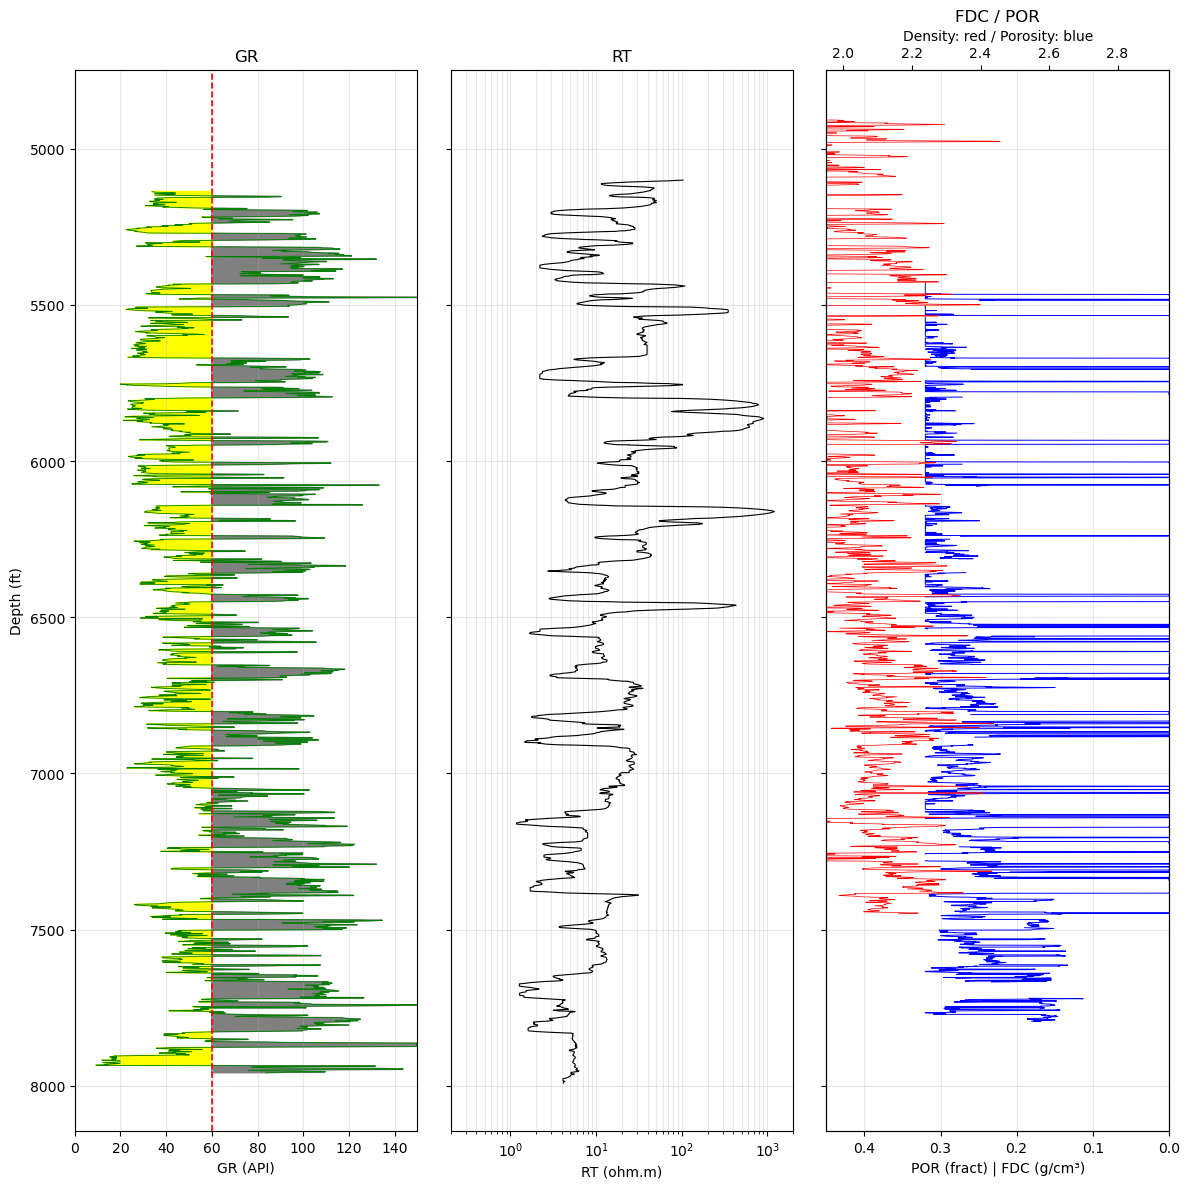

In [10]:
gr_cutoff = 60

# Industry Standard Ranges
ranges = {
    'GR_NM': (0, 150),
    'RT': (0.2, 2000),
    'POR': (0, 0.45),
    'FDC': (1.95, 2.95)
}

#  Four-track log plot
fig, ax = plt.subplots(1, 3, figsize=(12, 12), sharey=True)

depth = df['DEPT']

# Track 1: GR
ax[0].plot(df['GR_NM'], depth, color='green', lw=0.6)
ax[0].axvline(gr_cutoff, color='red', linestyle='--', lw=1.2, label=f'{gr_cutoff} API cutoff')
ax[0].fill_betweenx(df['DEPT'], gr_cutoff, df['GR_NM'], where = (df['GR_NM'] <= gr_cutoff), color ='yellow')
ax[0].fill_betweenx(df['DEPT'], gr_cutoff, df['GR_NM'], where = (df['GR_NM'] >= gr_cutoff), color ='grey')
ax[0].set_xlim(0,150)
ax[0].set_xlabel('GR (API)')
ax[0].set_ylabel('Depth (ft)')
ax[0].set_title('GR')
ax[0].invert_yaxis()  

# Track 2: RT (resistivity)
ax[1].plot(df['RT'], depth, color='black', lw=0.8)
ax[1].set_xlim(0.2,2000)
ax[1].set_xscale('log')
ax[1].set_xlabel('RT (ohm.m)')
ax[1].set_title('RT')
ax[1].grid(True, which = 'both', alpha=0.3)

# Track 3: FDC (RHOB) + POR (NPHI equivalent) on twin axes
ax[2].plot(df["POR"], depth, color="blue", lw=0.7)
ax[2].set_title("FDC / POR")
ax[2].set_xlabel("POR (fract) | FDC (g/cm³)")
ax[2].set_xlim(0.45,0)
# FDC (Density plot)
ax2 = ax[2].twiny()
ax2.plot(df["FDC"], depth, color="red", lw = 0.5, label ="FDC")
ax2.set_xlim(1.95,2.95)
ax2.set_xlabel("Density: red / Porosity: blue")



for axis in ax:
    axis.grid(True, alpha=0.3)

plt.tight_layout()

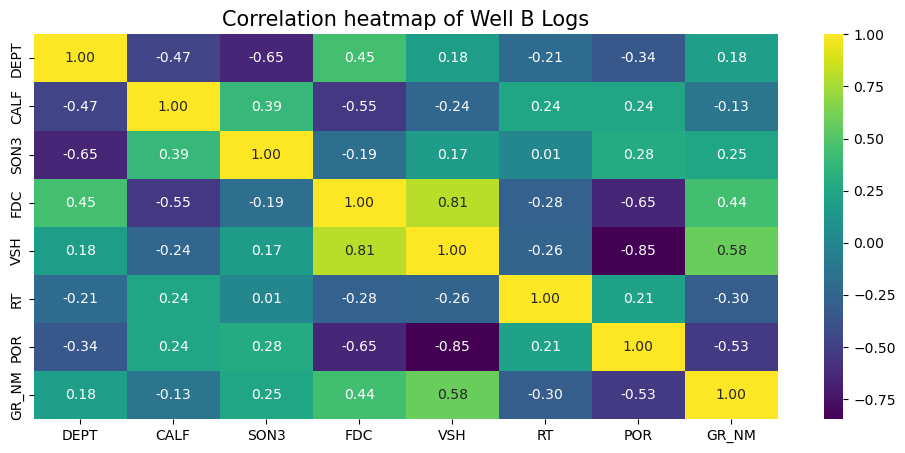

In [11]:
# Correlation between Gamma Ray, Resistivity, Density, and Porosity Logs
corr = df.corr()

plt.figure(figsize = (12,5))
sns.heatmap(corr, annot = True, cmap = 'viridis', fmt = '.2f')
plt.title('Correlation heatmap of Well B Logs', fontsize = 15);

## STATISTICAL FACIES DISCRIMINATION

• Generate a Histogram of the Gamma Ray (GR) values.

• Use the histogram to statistically justify the 60 API cutoff based on your understanding of the Geology of the Niger Delta.

• Judging from the distribution of GR, choose the most likely and a high-side GR cutoff and justify your answer.

• Highlight these cutoff values with a vertical line (axvline).

• What is the implication of the various GR cutoffs?

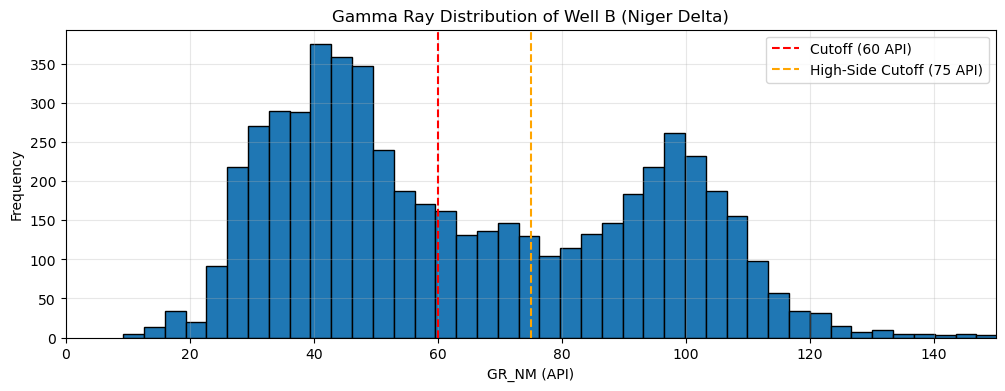

In [12]:
gr_cutoff = 60        # industry standard for Niger Delta
gr_highside = 75      # high-side cutoff 

plt.figure(figsize = (12,4))
plt.hist(df['GR_NM'], bins = 50, edgecolor = 'black')
plt.xlim(0,150)
plt.axvline(gr_cutoff,   color='red',    linestyle='--', lw =1.5, label=f'Cutoff ({gr_cutoff} API)')
plt.axvline(gr_highside, color='orange', linestyle='--', lw =1.5, label=f'High-Side Cutoff ({gr_highside} API)')
plt.xlabel('GR_NM (API)')
plt.ylabel('Frequency')
plt.title('Gamma Ray Distribution of Well B (Niger Delta)')
plt.legend()
plt.grid(True, alpha=0.3);

The histogram confirms a bimodal GR distribution (confirms interbedded sand-shale sequences of the Agbada Formation). 

Judging from the distribution of API values, there is a natural trough between the two populations at 73 API. However, because this coincides with a transition to high API values, sand properties are uncertain; therefore, a conservative API cutoff of 60 is used for sand discrimination.

The 75 API high-side cutoff captures marginal sands in the transition zone but risks inflating sand count with poor-quality rock.
A gr_cutoff of 60API gives a low but safe Net-to-gross because it sets a stricter criteria compared to a gr_cutoff of 75% where we are likely to include zones with poor reservoir properties (shale).

## FEATURE ENGINEERING (THE RQI)

• Create a new column titled RQI (Reservoir Quality Index) using the formula: RQI = Porosity * (1 - GR_norm).

• Explain the reason behind the normalization of GR values.

• Create a 2-tracl plot showing: (1) GR with a cutoff of 60 and (2) the New Reservoir Quality Index filling the area with good reservoir quality according to (Porosity * (1 - GR_norm)) and color as gold.

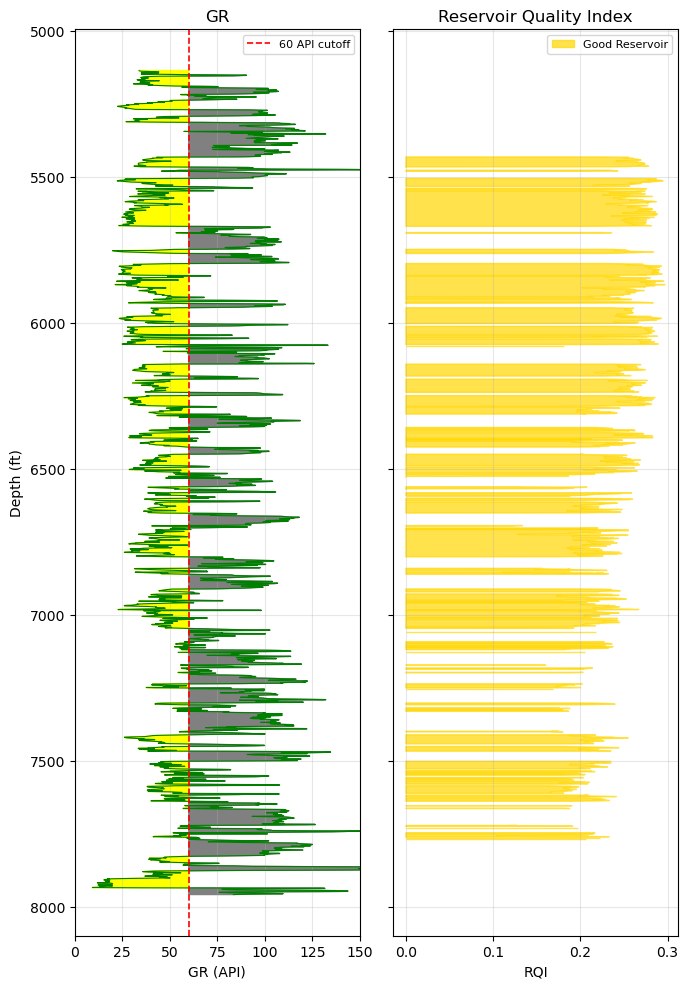

In [13]:
# 2-track plot showing: (1) GR with a cutoff of 60 and (2) the New Reservoir Quality Index
# filling the area with good reservoir quality according to (Porosity * (1 - GR_norm)) and color as gold.

# Normalize GR to 0–1 range
df['GR_norm'] = (df['GR_NM'] - df['GR_NM'].min()) / (df['GR_NM'].max() - df['GR_NM'].min())

# Calculate RQI
df['RQI'] = df['POR'] * (1 - df['GR_norm'])

# 2-track plot
fig, ax = plt.subplots(1, 2, figsize=(7,10), sharey=True)

# Track 1: GR
ax[0].plot(df['GR_NM'], depth, color='green', lw=0.8)
ax[0].axvline(gr_cutoff, color='red', linestyle='--', lw=1.2, label=f'{gr_cutoff} API cutoff')
ax[0].fill_betweenx(df['DEPT'], gr_cutoff, df['GR_NM'], where = (df['GR_NM'] <= gr_cutoff), color ='yellow')
ax[0].fill_betweenx(df['DEPT'], gr_cutoff, df['GR_NM'], where = (df['GR_NM'] >= gr_cutoff), color ='grey')
ax[0].set_xlim(0,150)
ax[0].set_xlabel('GR (API)')
ax[0].set_ylabel('Depth (ft)')
ax[0].set_title('GR')
ax[0].legend(fontsize=8)
ax[0].invert_yaxis()
ax[0].grid(True, alpha=0.3)

# Track 2: RQI 
ax[1].fill_betweenx(depth, 0, df['RQI'], where = (df['GR_NM'] <= gr_cutoff), color='gold', alpha = 0.7, label = 'Good Reservoir')
ax[1].set_xlabel('RQI')
ax[1].set_title('Reservoir Quality Index')
ax[1].legend(fontsize=8)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()

This moves the analysis from "where is the sand?" to "where is the most productive sand?

GR Normalization scales raw GR values to a 0–1 range, making the index dimensionless and comparable across wells with different GR baselines.
A GR_norm of 0 = cleanest sand, 1 = purest shale.

The left track shows where the rock is "Clean" (Yellow). However, the right track (RQI) shows where the rock is both Clean and Highly Porous.

The gold fill highlights only intervals with GR ≤ 60 API, isolating the best-quality reservoir rock in the well.

### NETPAY QUANTIFICATION

• Apply complex boolean filtering to identify "pay sands" where GR <= 60 AND Porosity >= 0.15.

• Calculate the reservoir Gross Thickness in meters (using the 0.1524m sample rate)

• Calculate the Net Pay Thickness in meters (using the 0.1524m sample rate).

• Calculate NTG

• Create a 3-track plot showing: (1) GR with Cutoff, (2) Porosity plot with cutoff, and (3) The Net Pay "Gold" flags.

Net Pay: This is where we answer the defining question of  — what is the total thickness, in meters, of intervals that satisfy both our GR and porosity cutoffs? That cumulative figure represents the reservoir's viable pay zones (Net Pay). The Net-to-Gross ratio (ntg) is then calculated by dividing the net pay thickness by the total gross sand thickness and expressing the result as a percentage.

In [14]:
sample_rate = 0.1524    # Converting our 0.5ft sampling interval to metres.
por_cutoff = 0.15

df['pay_sands'] =  (df['GR_NM'] <= gr_cutoff) & (df['POR'] >= por_cutoff)

RGT = len(df) * sample_rate 
print(f' Our Reservoir Gross Thickness is {RGT:.2f}m')

Net_pay = (df['pay_sands'].sum() * sample_rate)   # Samples that satisfy the condition above
print(f' Our Net-Pay Thickness is {Net_pay:.2f}m')

ntg = Net_pay / RGT
print(f' Our Net-to-Gross Thickness is {ntg * 100:.2f}%')

 Our Reservoir Gross Thickness is 941.98m
 Our Net-Pay Thickness is 379.02m
 Our Net-to-Gross Thickness is 40.24%


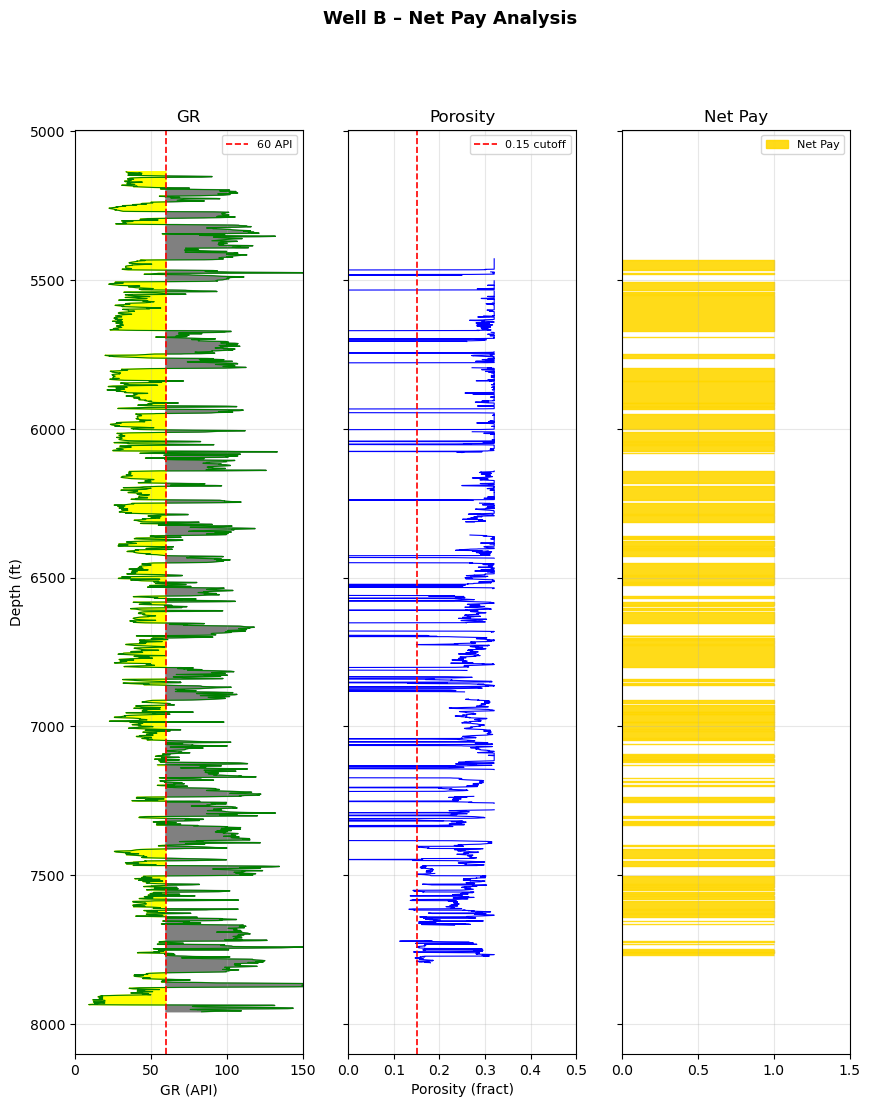

In [15]:
# 3-track plot showing: (1) GR with Cutoff, (2) Porosity plot with cutoff, and (3) The Net Pay "Gold" flags.
fig, ax = plt.subplots(1, 3, figsize=(10, 12), sharey=True)
fig.suptitle("Well B – Net Pay Analysis", fontsize=13, fontweight='bold')


# Track 1: GR with cutoff
ax[0].plot(df['GR_NM'], depth, color='green', lw=0.8)
ax[0].axvline(gr_cutoff, color='red', linestyle='--', lw=1.2, label=f'{gr_cutoff} API')
ax[0].fill_betweenx(df['DEPT'], gr_cutoff, df['GR_NM'], where = (df['GR_NM'] <= gr_cutoff), color ='yellow')
ax[0].fill_betweenx(df['DEPT'], gr_cutoff, df['GR_NM'], where = (df['GR_NM'] >= gr_cutoff), color ='grey')
ax[0].set_xlim(0,150) 
ax[0].set_xlabel('GR (API)')
ax[0].set_ylabel('Depth (ft)')
ax[0].set_title('GR')
ax[0].legend(fontsize=8)
ax[0].invert_yaxis()
ax[0].grid(True, alpha=0.3)

# Track 2: Porosity with cutoff
ax[1].plot(df['POR'], depth, color='blue', lw=0.8)
ax[1].axvline(por_cutoff, color='red', linestyle='--', lw=1.2, label=f'{por_cutoff} cutoff')
ax[1].set_xlim(0, 0.5)
ax[1].set_xlabel('Porosity (fract)')
ax[1].set_title('Porosity')
ax[1].legend(fontsize=8)
ax[1].grid(True, alpha=0.3)

# Track 3: Net Pay flag 
ax[2].fill_betweenx(depth, 0, df['pay_sands'], where=(df['pay_sands'] == 1), color='gold', alpha=0.9, label='Net Pay')
ax[2].set_xlim(0, 1.5)
ax[2].set_title('Net Pay')
ax[2].legend(fontsize=8)
ax[2].grid(True, alpha=0.3)

Track 1 (Lithology Filter): Displays all clean sands (GR ≤ 60 API).

Track 2 (Porosity Filter): Displays all porous zones (POR ≥ 0.15).

Track 3 (The Pay Zone): This is the intersection of both criteria. The gold bars represent the "Pay Sands (intervals that are both clean enough to flow and porous enough to store).

The Bottom Line: Out of a well thickness of 941.98m, we have successfully quantified a NetPay of 379.02m. This results in a Net-to-Gross (NTG) ratio of 40.24%, providing a clear, data-driven metric for calculating the total volume of hydrocarbons in place